In [1]:
import pandas as pd

# Load data
df = pd.read_csv("D:\\New folder\\Cars_data (1).csv")

# Clean numeric columns with commas and strings at the end (e.g., "10,000 km", "15.5 L", "100 bhp")
numeric_cols = ["price", "km_driven", "mileage_new", "max_engine_capacity_new"]
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)  # Ensure all values are strings
        .str.replace(",", "", regex=False)  # Remove commas
        .str.extract(r"([0-9.]+)")  # Extract numeric part using regex
        .squeeze()  # Convert DataFrame to Series if needed
        .astype(float)  # Convert to float
    )

# Verify the cleaned columns
print(df[numeric_cols].head())


      price  km_driven  mileage_new  max_engine_capacity_new
0  950000.0   150000.0        12.99                   2494.0
1  500000.0    53755.0        15.10                   2179.0
2  738000.0    53838.0        18.53                   1199.0
3  850000.0    28112.0        15.80                   1591.0
4  899999.0    63125.0        24.52                   1248.0


In [2]:
# Example: "100.6bhp@3600rpm" → 100.6
df["max_power"] = df["Max Power"].str.extract(r"(\d+\.\d+|\d+)").astype(float)
df["max_torque"] = df["Max Torque"].str.extract(r"(\d+\.\d+|\d+)").astype(float)


In [3]:
# Drop rows with missing price
df.dropna(subset=["price"], inplace=True)

# Fill missing values
df["mileage_new"].fillna(df["mileage_new"].median())

0        12.99
1        15.10
2        18.53
3        15.80
4        24.52
         ...  
34028    17.42
34029    27.39
34030    18.60
34031    18.60
34032    21.21
Name: mileage_new, Length: 34033, dtype: float64

In [4]:
df["max_power"].fillna(df["max_power"].median())
df["max_torque"].fillna(df["max_torque"].median())

0        200.0
1        330.0
2        113.0
3        151.0
4        200.0
         ...  
34028    320.0
34029    190.0
34030    114.7
34031    114.7
34032    113.0
Name: max_torque, Length: 34033, dtype: float64

In [5]:
# Remove rows where 'max_engine_capacity_new' is equal to 0
df = df[df['max_engine_capacity_new'] != 0]

In [6]:
import numpy as np

# Define columns to check for outliers
log_cols = ['max_power', 'max_torque', 'max_engine_capacity_new', 'price']

# For each column, remove rows where the value is outside 1.5*IQR from Q1 or Q3
for col in log_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [7]:
import numpy as np

df["log_max_power"] = np.log(df["max_power"])
df["log_max_torque"] = np.log(df["max_torque"])
df["log_max_engine_capacity_new"] = np.log(df["max_engine_capacity_new"])


In [8]:
import numpy as np

features = [
    
 "km_driven", "mileage_new", 
    "log_max_power", "log_max_torque", "price",
 "log_max_engine_capacity_new"

]

df = df.dropna(subset=["price"])
df = df.dropna(subset=features)
X = df[features]
y = df["price"]
#y = np.log(df["price"])  # Natural logarithm (base e)

In [9]:
# Identify negative values in 'max_engine_capacity_new'
neg_values = df[df['max_engine_capacity_new'] < 0]
print("Rows with negative 'max_engine_capacity_new':")
print(neg_values[['max_engine_capacity_new']])
print(f"Total negative values: {len(neg_values)}")

Rows with negative 'max_engine_capacity_new':
Empty DataFrame
Columns: [max_engine_capacity_new]
Index: []
Total negative values: 0


In [10]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


X_train, X_val = train_test_split(X,test_size=0.2,random_state=44,shuffle=True)
y_train, y_val = train_test_split(y,test_size=0.2,random_state=44,shuffle=True)



scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


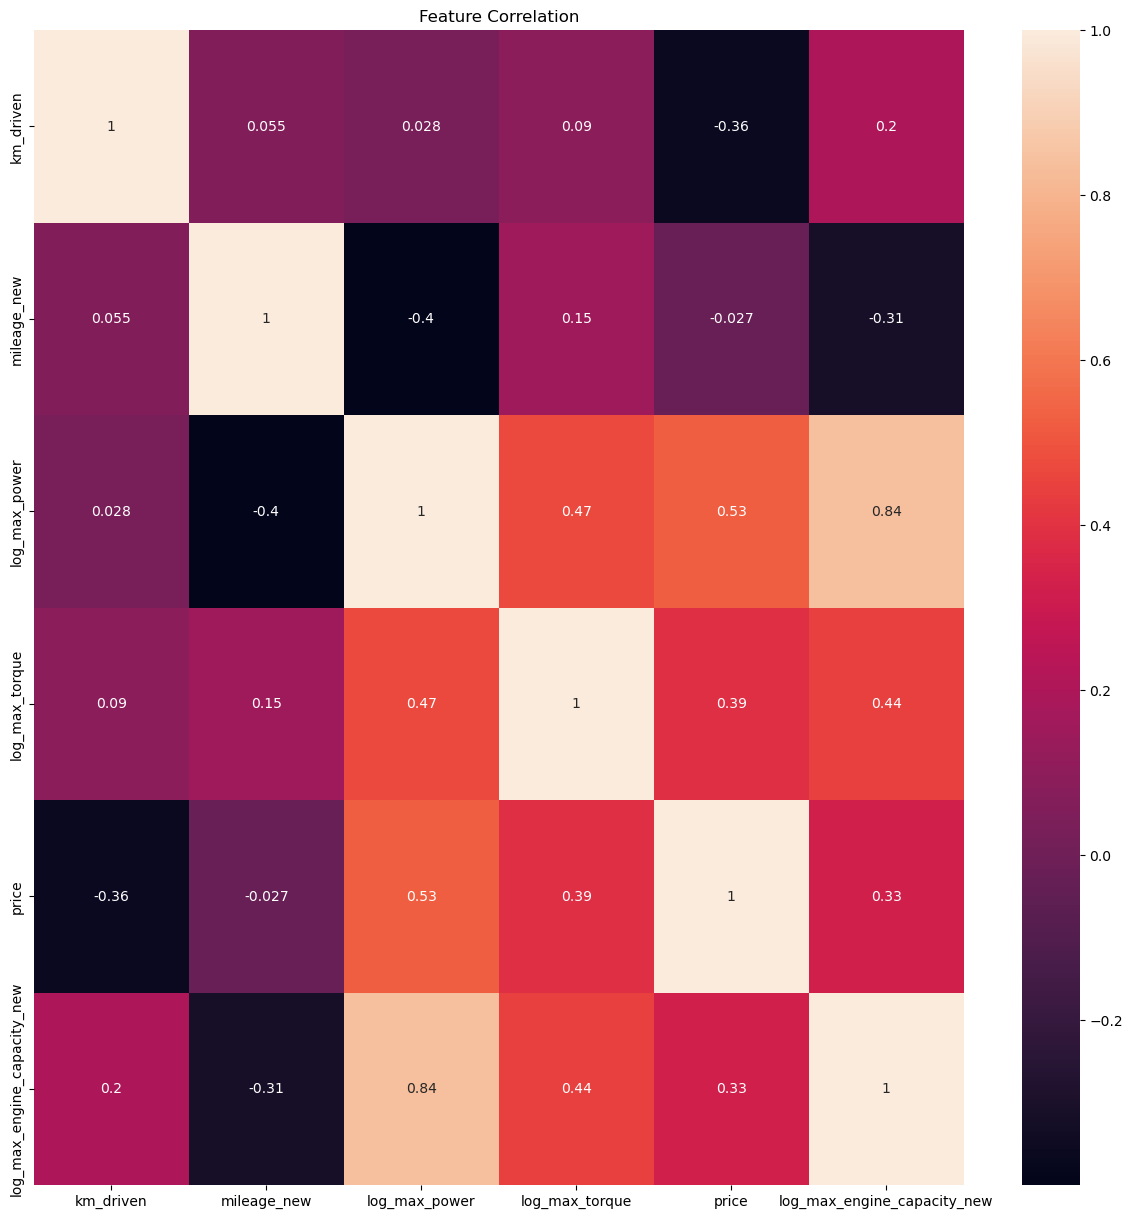

In [11]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

plt.figure(figsize=(15, 15))

sns.heatmap(df[[
"km_driven", "mileage_new", 
    "log_max_power", "log_max_torque", "price",
 "log_max_engine_capacity_new"
]].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

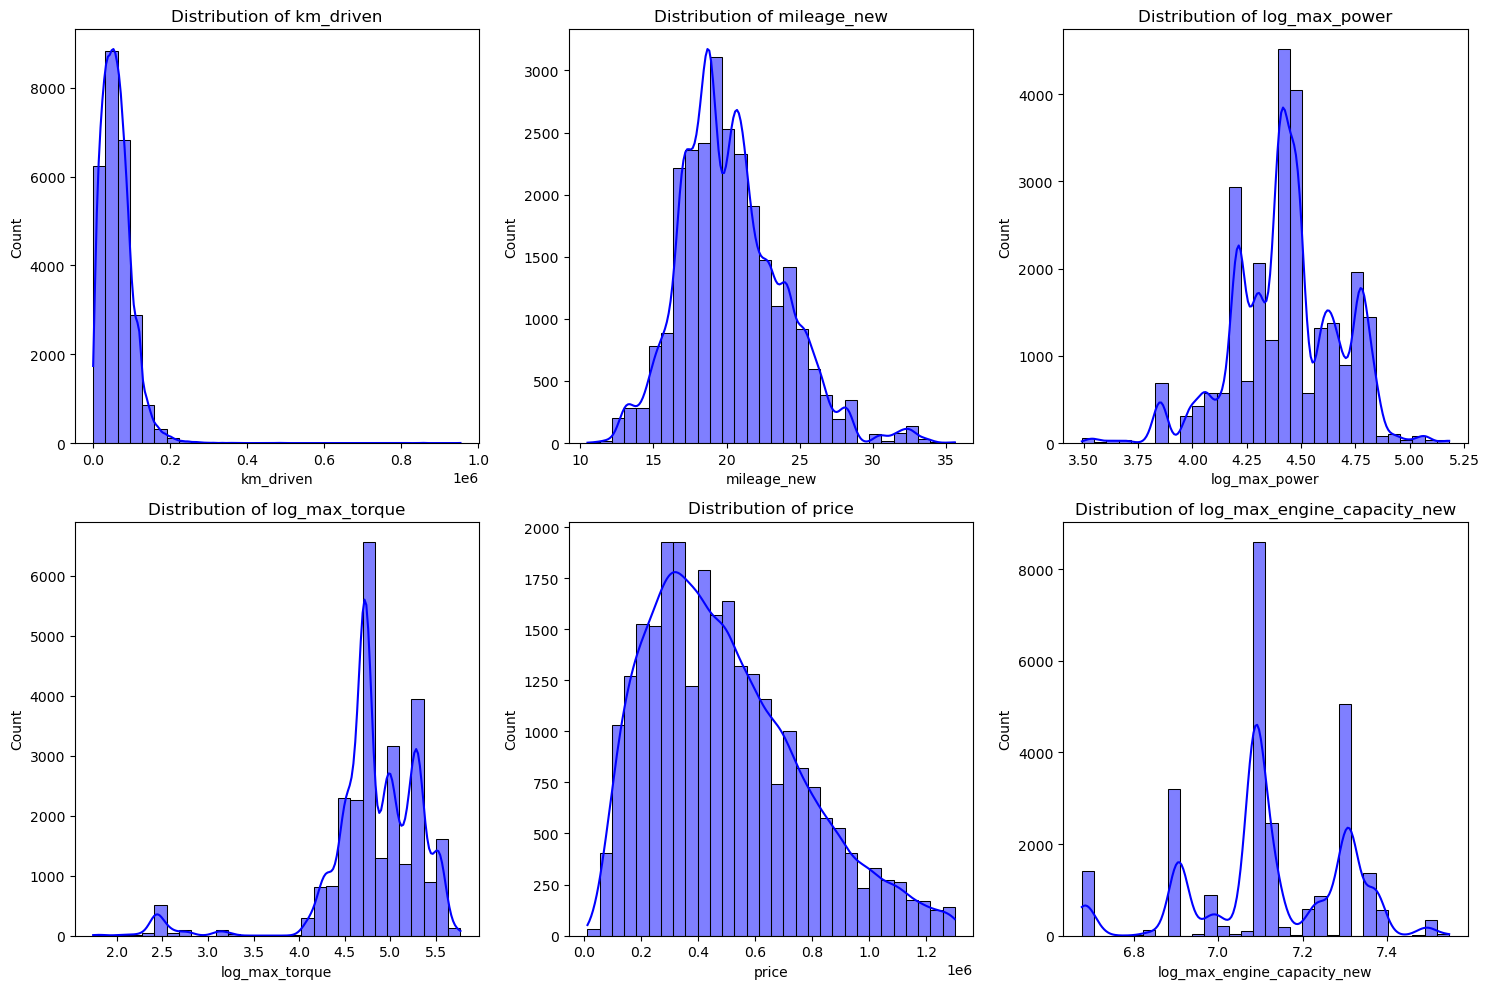

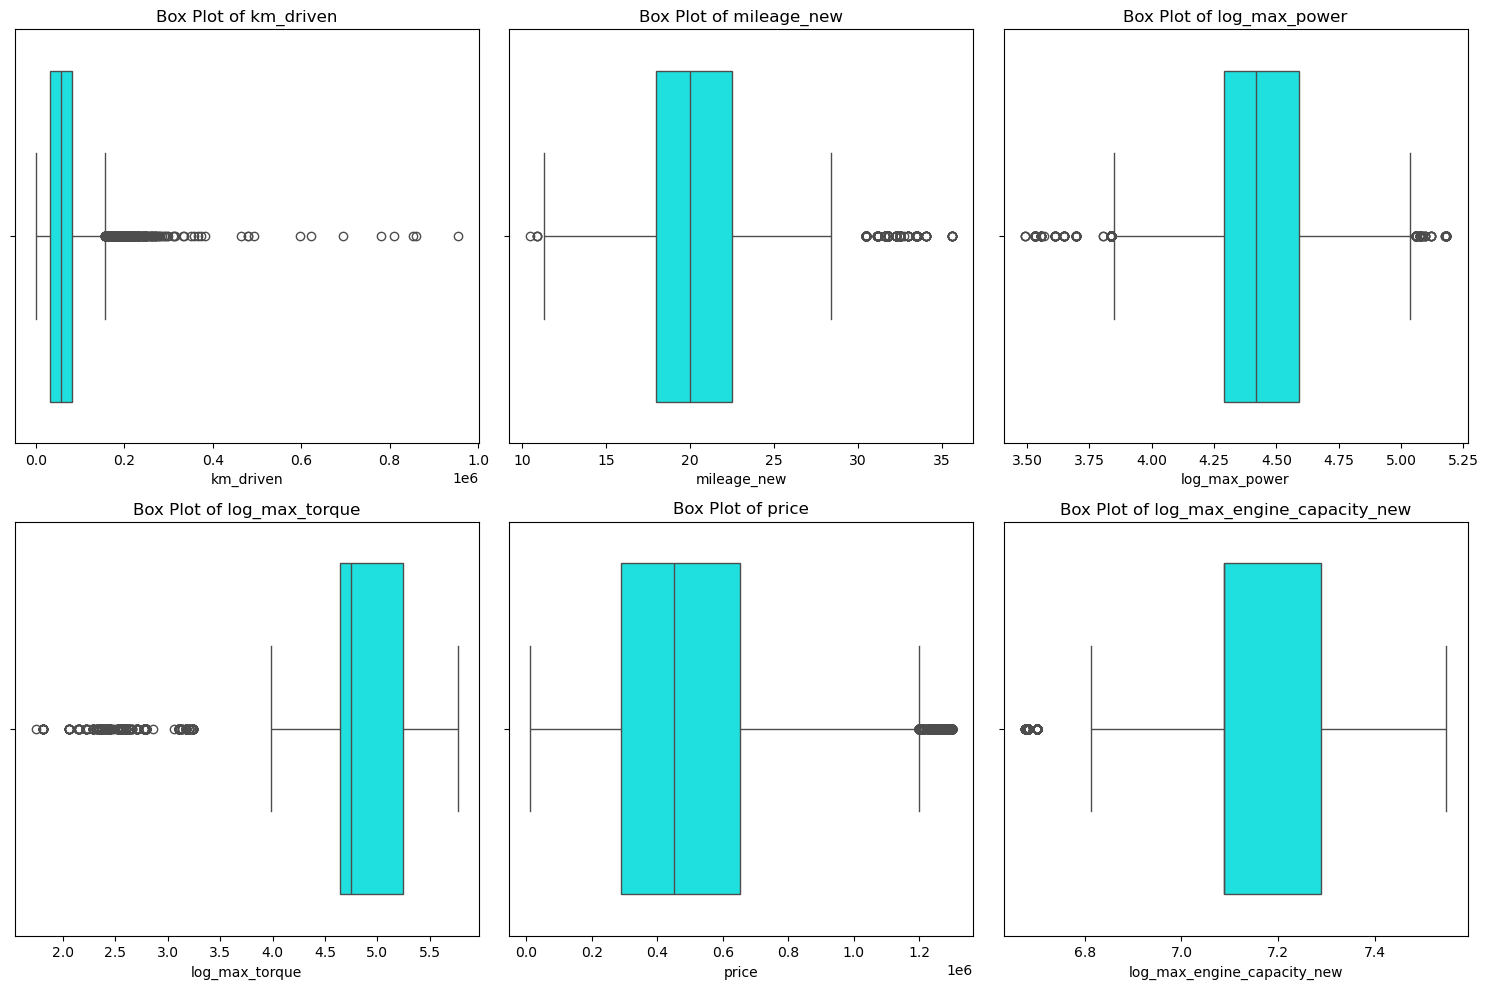

In [12]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (including int, float, bool)
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "log_max_power", "log_max_torque", "price",
    "log_max_engine_capacity_new"
]

# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model1 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model1.summary()
model1.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,537 (68.50 KB)

 Trainable params: 17,537 (68.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model1.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))

Epoch 1/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 316006400000.0000 - mae: 494006.0938 - val_loss: 301192708096.0000 - val_mae: 480644.8438
Epoch 2/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 297020751872.0000 - mae: 475178.8438 - val_loss: 243256279040.0000 - val_mae: 419925.5938
Epoch 3/70
654/654 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 220881354752.0000 - mae: 392910.2188 - val_loss: 129108951040.0000 - val_mae: 276755.8438
Epoch 4/70
421/654 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 112949370880.0000 - mae: 253907.5781

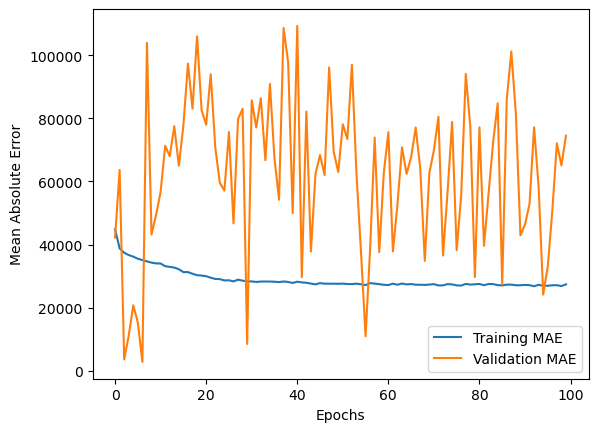

In [ ]:
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model2 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model1.summary()
model1.compile(optimizer="adam", loss="mse", metrics=["mae"])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,537 (68.50 KB)

 Trainable params: 17,537 (68.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model2.fit(X_train, y_train, epochs=70,validation_data=(X_val, y_val))

ValueError: You must call `compile()` before using the model.

In [ ]:
import matplotlib.pyplot as plt
# Plot training history
plt.plot(history.history['mse'], label='Training MAE')
plt.plot(history.history['val_mse'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()